In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
import os

os.makedirs("graphs", exist_ok=True)

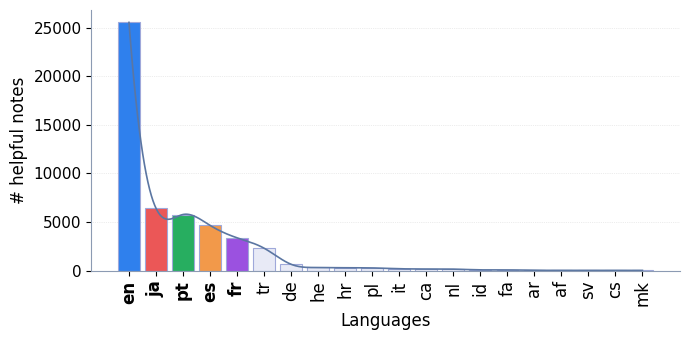

In [2]:
# Language distribution of helpful non-media notes in CRH
counts = {
"en": 25524, "ja": 6421, "pt": 5779, "es": 4661, "fr": 3382,
"tr": 2315, "de": 661, "he": 333, "hr": 303, "pl": 286,
"it": 203, "ca": 176, "nl": 164, "id": 88, "fa": 83,
"ar": 44, "af": 42, "sv": 39, "cs": 38, "mk": 33,
"th": 32, "ko": 23, "no": 22, "tl": 19, "fi": 17,
"da": 14, "sl": 13, "ru": 12, "hi": 10, "hu": 9,
"et": 8, "so": 8, "ro": 6, "sq": 6, "cy": 6,
"el": 5, "sw": 4, "sk": 3, "lt": 3, "vi": 2,
"ur": 1, "lv": 1, "gu": 1, "ta": 1, "zh-cn": 1,
}

s = pd.Series(counts).sort_values(ascending=False)
# Keeping top-k languges and drop the rest for better visualization
s = s.head(20)

# Vibrant but still paper-friendly palette for selected languages
top5_colors = {
    "en": "#2F80ED", # blue
    "ja": "#EB5757", # red
    "pt": "#27AE60", # green
    "es": "#F2994A", # orange
    "fr": "#9B51E0", # purple
}

muted_color = "#E8EAF6" # A lighter grey/blue to match the image's bar fill

# Assign colors
colors = []
for lang in s.index:
    if lang in top5_colors:
        colors.append(top5_colors[lang])
    else:
        colors.append(muted_color)

# Increased width to fit all x-axis labels
fig, ax = plt.subplots(figsize=(7, 3.5)) 

# Create vertical bars
bars = ax.bar(
    s.index,
    s.values,
    color=colors,
    edgecolor="#9FA8DA", # Light blue border similar to the image
    linewidth=0.8,
)

# Add a smooth curve over the histogram
x = np.arange(len(s))
# Interpolate for a smooth line
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, s.values, k=3)
y_smooth = spl(x_smooth)
y_smooth = np.clip(y_smooth, 0, None) # Prevent the curve from dipping below 0

ax.plot(x_smooth, y_smooth, color="#5B76A2", linewidth=1.2)

# Axis labels and formatting
ax.set_ylabel("# helpful notes", fontsize=12)
ax.set_xlabel("Languages", fontsize=12)
ax.tick_params(axis="x", labelsize=12, rotation=90) # Rotate x-axis labels
ax.tick_params(axis="y", labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Optional: colour bottom and left spines to match the image style
ax.spines["bottom"].set_color("#8C9BB3")
ax.spines["left"].set_color("#8C9BB3")

# Switch grid to horizontal (y-axis)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.45)
ax.set_axisbelow(True)

# Highlight selected languages in x-axis labels
for tick in ax.get_xticklabels():
    if tick.get_text() in top5_colors:
        tick.set_fontweight("bold")

plt.tight_layout()
plt.savefig("graphs/cf_note_CRH_lang_dist.pdf", bbox_inches="tight")
plt.show()

In [3]:
df = pd.read_csv("../data/CF/cf_v1.csv")
df_train = pd.read_csv("../data/CF/cf_v1_train.csv")
df_test = pd.read_csv("../data/CF/cf_v1_test.csv")

def print_label_distribution(df):
    # Count True/False for each domain-language pair
    counts = (
        df.groupby(['domain', 'language', 'label'])
        .size()
        .unstack(fill_value=0)
    )

    # Ensure both True and False columns exist
    for col in [True, False]:
        if col not in counts.columns:
            counts[col] = 0

    # Create formatted string: "true_count/false_count"
    counts['value'] = (
        counts[True].astype(str) + "/" + counts[False].astype(str)
    )

    # Create matrix table
    matrix = counts['value'].unstack(fill_value="0/0")

    print(matrix)

print("Full data:")
print_label_distribution(df)
print("\nTrain data:")
print_label_distribution(df_train)
print("\nTest data:")
print_label_distribution(df_test)

Full data:
language         en        es       fr        ja       pt
domain                                                   
finance     996/506   209/125   165/99   197/121  404/111
politics  3753/2530  1073/672  908/516  1571/878  694/464

Train data:
language         en       es       fr        ja       pt
domain                                                  
finance     685/316   127/73    97/61    117/74   267/41
politics  3435/2347  762/482  591/333  1252/697  391/266

Test data:
language       en       es       fr       ja       pt
domain                                               
finance   311/190    82/52    68/38    80/47   137/70
politics  318/183  311/190  317/183  319/181  303/198
